# Семинар 1. Линейная регрессия

#### Шаг 1. Загрузка датасета и вывод на экран

In [ ]:
import pandas as pd

# Датасет должен лежать рядом с ноутбуком.
df = pd.read_csv("delivery_dataset.csv")
df.head()

#### Шаг2. Разделение выборки на тренировочную, валидационную и тестовую с выбором нужных столбцов:
* в тренировочной: 300 первых заказов;
* в валидационной: 100 следующих; 
* в тестовой: 100 последних.

In [ ]:
features = [
    "Расстояние до клиента (в км)",
    "Количество позиций в чеке (в шт.)",
    "Балл пробок на дорогах (в баллах)",
    "Погода (в градусах Цельсия)",
    "Этаж доставки (в этажах)"
]

X = df[features]
y = df["Время доставки (в минутах)"]

assert len(df) == 500, "По условию в датасете должно быть 500 заказов"

X_train = X.iloc[:300]
y_train = y.iloc[:300]
X_val = X.iloc[300:400]
y_val = y.iloc[300:400]
X_test = X.iloc[400:500]
y_test = y.iloc[400:500]

print("train:", len(X_train), "val:", len(X_val), "test:", len(X_test))

#### Вопрос 1. 

Для чего мы разбиваем данные на выборки? Для чего нам нужна тренировачная, для чего валидационная, для чего тестовая?

На тренировочной выборке модель подбирает веса. На валидационной проверяем качество и выбираем настройки. Тестовую оставляем для итоговой проверки, чтобы оценить модель на данных, под которые её не подгоняли.

#### Шаг 3. Установка sklearn чтобы обучать модель линейной регрессии через Ridge

In [ ]:
%pip install -q scikit-learn

#### Шаг 4. Обучение модели линейной регрессии на тренировочной выборке с помощью Ridge и sparse_cg

In [ ]:
from sklearn.linear_model import Ridge

# При alpha=0 регуляризация отключена.
model = Ridge(alpha=0.0, solver="sparse_cg", tol=1e-10, max_iter=1000)
model.fit(X_train, y_train)

#### Шаг 5. Вывод на экран графиков ошибок (SSE, MSE, RMSE) в зависимости от итераций для train и val выборок.

Для графиков считаю шаги метода сопряжённых градиентов отдельно. Это та же задача без регуляризации, но не история внутренних итераций объекта `Ridge`. На тесте использую модель из шага 4.

Графики ниже сохранены из предыдущего выполненного ноутбука. Для повторного расчёта нужен исходный `delivery_dataset.csv`.

Количество итераций: 7
Норма невязки: 1.2332750248698523e-08
RMSE на train: 4.29 мин
RMSE на val: 4.56 мин


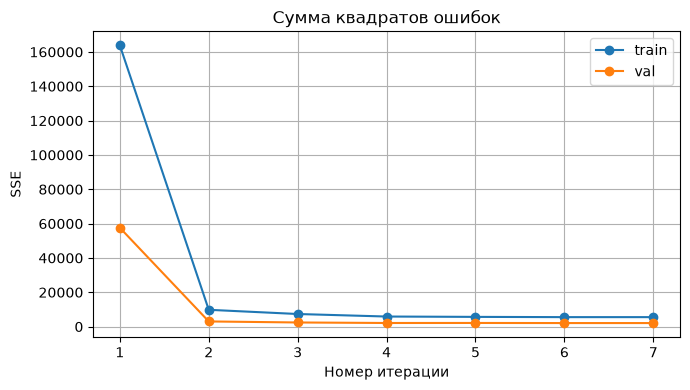

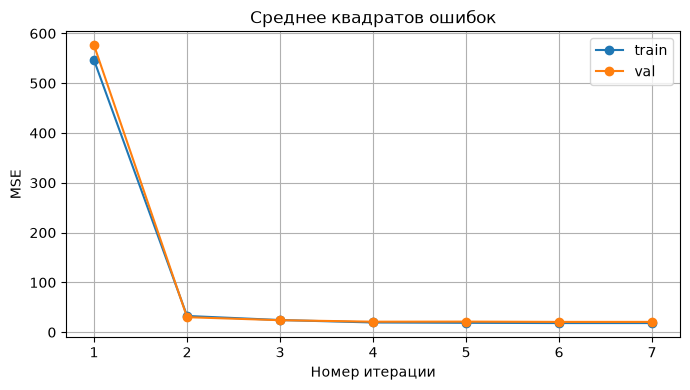

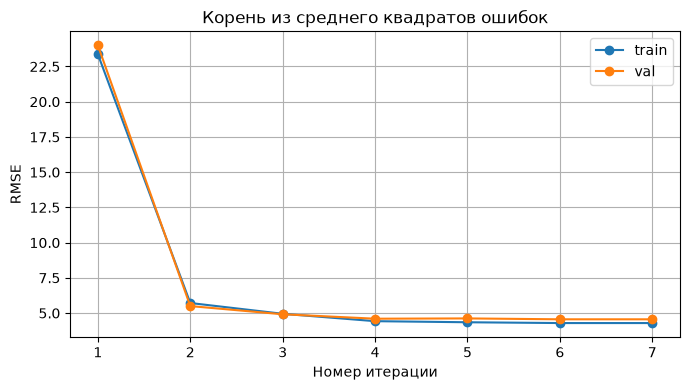

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


X_train_cg = np.column_stack((np.ones(len(X_train)), X_train.to_numpy()))
X_val_cg = np.column_stack((np.ones(len(X_val)), X_val.to_numpy()))

A = X_train_cg.T @ X_train_cg
b = X_train_cg.T @ y_train.to_numpy()

w = np.zeros(X_train_cg.shape[1])
r = b - A @ w
p = r.copy()

epsilon = 1e-3
max_iter = 1000
iteration = 0

sse_train = []
sse_val = []
mse_train = []
mse_val = []
rmse_train = []
rmse_val = []

while np.linalg.norm(r) >= epsilon and iteration < max_iter:
    alpha_k = (r @ r) / (p @ A @ p)
    w = w + alpha_k * p
    r_new = r - alpha_k * (A @ p)

    train_error = X_train_cg @ w - y_train.to_numpy()
    val_error = X_val_cg @ w - y_val.to_numpy()

    sse_train.append(np.sum(train_error ** 2))
    sse_val.append(np.sum(val_error ** 2))
    mse_train.append(np.mean(train_error ** 2))
    mse_val.append(np.mean(val_error ** 2))
    rmse_train.append(np.sqrt(mse_train[-1]))
    rmse_val.append(np.sqrt(mse_val[-1]))

    beta_k = (r_new @ r_new) / (r @ r)
    p = r_new + beta_k * p
    r = r_new
    iteration = iteration + 1

print('Количество итераций:', iteration)
print('Норма невязки:', np.linalg.norm(r))
print('RMSE на train:', round(rmse_train[-1], 2), 'мин')
print('RMSE на val:', round(rmse_val[-1], 2), 'мин')

iterations = range(1, iteration + 1)

plt.figure(figsize=(7, 4))
plt.plot(iterations, sse_train, marker='o', label='train')
plt.plot(iterations, sse_val, marker='o', label='val')
plt.xlabel('Номер итерации')
plt.ylabel('SSE')
plt.title('Сумма квадратов ошибок')
plt.xticks(iterations)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(iterations, mse_train, marker='o', label='train')
plt.plot(iterations, mse_val, marker='o', label='val')
plt.xlabel('Номер итерации')
plt.ylabel('MSE')
plt.title('Среднее квадратов ошибок')
plt.xticks(iterations)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(iterations, rmse_train, marker='o', label='train')
plt.plot(iterations, rmse_val, marker='o', label='val')
plt.xlabel('Номер итерации')
plt.ylabel('RMSE')
plt.title('Корень из среднего квадратов ошибок')
plt.xticks(iterations)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


#### Вопрос 2.

Какую информацию про нашу модель несут эти графики?

Графики показывают, как меняются ошибки на train и val во время обучения. Если ошибка train падает, а val устойчиво растёт, это признак переобучения. SSE зависит от числа заказов, поэтому при наших 300 и 100 строках качество лучше сравнивать по MSE или RMSE.

#### Вопрос 3. 

Какая траектория линий train и val ошибок будет на графиках недообученной модели и почему?


Какая траектория линий train и val ошибок будет на графиках обученной модели и почему?


Какая траектория линий train и val ошибок будет на графиках переобученной модели и почему?

При недообучении обе линии остаются высоко: ошибки ещё большие и на train, и на val. Модель либо не успела нормально обучиться, либо слишком простая для этой задачи.
У нормально обученной модели обе линии сначала падают, потом выравниваются внизу. Ошибки небольшие, потому что модель научилась предсказывать и знакомые, и новые данные.
При переобучении train продолжает падать, а val начинает расти. Получается, на знакомых примерах модель работает всё лучше, а на новых — хуже, потому что слишком подстроилась под обучающие данные.

#### Шаг 6. Применение модели на тестовой выборке

In [ ]:
y_pred = model.predict(X_test)

result = pd.DataFrame({
    "Настоящее время, мин": y_test.to_numpy(),
    "Прогноз, мин": y_pred
})
result.round(2)

#### Шаг 7. RMSE на тестовой выборке

In [ ]:
rmse_test = np.sqrt(np.mean((y_test.to_numpy() - y_pred) ** 2))
print(f"RMSE на test: {rmse_test:.2f} мин")

#### Вопрос 4.

Что получившийся RMSE может сказать о нашей модели?

В расчёте RMSE получилась около 4,83 минуты. Это среднеквадратичная ошибка прогноза времени доставки, а не максимальная: отдельные промахи могут быть больше. Насколько такой точности достаточно, зависит от требований к доставке.